<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8012/blob/main/laboratorio_calificado_2_v1.0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio Calificado N° 2
**Curso**: MCD8012 - Visión Computacional

**Universidad**: UTEC

**Profesor**: Itamar Salazar

**Integrantes**:
- David Jimenez
- José Carlos Nomberto

## Ejercicio 1: Clasificador usando Regresión Logística

### Descripción

Entrenar un modelo de regresión logística para clasificar imágenes entre 3 tipos de
clases. Para ello escoja 3 clases entre las 10 que ofrece el dataset de CIFAR-10.

In [ ]:
# Importar librerías de python

In [1]:
import cv2
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


### Tarea 1 - Carga de Datos y Selección de Clases

Cargar del dataset CIFAR-10 y extraer solo 3 clases para el entrenamiento (use
cifar10.load_data() y use los valores por defecto que devuelve)

In [1]:
# Cargar datos
print(f'\nCargado de Datos')
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(f'\nTamaño de Dataset Completo')
print(f' - Tamaño de x_train: {x_train.shape}')
print(f' - Tamaño de x_test: {x_test.shape}')
print(f' - Tamaño de y_train: {y_train.shape}')
print(f' - Tamaño de y_test: {y_test.shape}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Tamaño de x_train: (50000, 32, 32, 3)
Tamaño de x_test: (10000, 32, 32, 3)
Tamaño de y_train: (50000, 1)
Tamaño de y_test: (10000, 1)


In [2]:
# Aplanar las etiquetas (vienen como matrices de 1 columna)
y_train = y_train.flatten()
y_test = y_test.flatten()

Tamaño de x_train: (50000, 32, 32, 3)
Tamaño de x_test: (10000, 32, 32, 3)
Tamaño de y_train: (50000,)
Tamaño de y_test: (10000,)


In [4]:
# Nombres originales de las clases en CIFAR-10 para referencia
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Clases seleccionadas: 3 (cat), 5 (dog), 8 (ship)
class1_id = 3
class2_id = 5
class3_id = 8
selected_classes = [class1_id, class2_id, class3_id]
class_mapping = {original: new for new, original in enumerate(selected_classes)}
print(f'Clase 1 (3): {class_names[class1_id]}')
print(f'Clase 2 (5): {class_names[class2_id]}')
print(f'Clase 3 (8): {class_names[class3_id]}')

# Crear máscaras para filtrar los datos
train_mask = np.isin(y_train, selected_classes)
test_mask = np.isin(y_test, selected_classes)

# Filtrar imágenes
x_train_bin = x_train[train_mask]
y_train_bin = y_train[train_mask]
x_test_bin = x_test[test_mask]
y_test_bin = y_test[test_mask]

Clase 1 (3): cat
Clase 2 (5): dog
Clase 3 (8): ship
Tamaño de x_train_bin: (15000, 32, 32, 3)
Tamaño de x_test_bin: (3000, 32, 32, 3)
Tamaño de y_train_bin: (15000,)
Tamaño de y_test_bin: (3000,)


In [5]:
# Re-mapeo de etiquetas para las clases seleccionadas
y_train_bin = np.array([class_mapping[label] for label in y_train_bin])
y_test_bin = np.array([class_mapping[label] for label in y_test_bin])

# Mostrar tamaños Dataset filtrado y re-mapeado
print(f'\nTamaño de Dataset Filtrado y Re-mapeado')
print(f' - Tamaño de x_train_bin: {x_train_bin.shape}')
print(f' - Tamaño de x_test_bin: {x_test_bin.shape}')
print(f' - Tamaño de y_train_bin: {y_train_bin.shape}')
print(f' - Tamaño de y_test_bin: {y_test_bin.shape}')

Número de imágenes de entrenamiento binarias: 15000
Número de imágenes de prueba binarias: 3000


### Tarea 2 - Función de Extracción de Características

Crear una función que extraiga 8 características de cada imagen (en este caso
usaremos los canales R,G,B,H,S,V, bordes horizontales de sobel y bordes
verticales de sobel )

In [6]:
def extract_features(image: np.ndarray, sobel_ksize: int = 3):
    """
    Extrae un vector de características de una imagen RGB de 32x32:

    - RGB original (3 canales)
    - HSV (3 canales)
    - Sobel horizontal y vertical sobre la escala de grises (2 canales)

    Devuelve un vector 1D de longitud 8*32*32 (8 canales x 32 width x 32 height)
    """
    # Normalizar a rango [0, 1]
    img_rgb = image.astype(np.float32) / 255.0

    # HSV
    img_hsv = cv2.cvtColor((img_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32) / 255.0

    # Escala de grises para bordes
    gray = cv2.cvtColor((img_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

    # Sobel horizontal y vertical
    sobelx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=sobel_ksize)
    sobely = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=sobel_ksize)

    # Normalizar bordes al rango [0, 1] usando valores absolutos
    sobelx_norm = cv2.normalize(np.abs(sobelx), None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
    sobely_norm = cv2.normalize(np.abs(sobely), None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

    # Apilar canales en profundidad -> dimensiones: 32x32x8
    features = np.dstack((img_rgb, img_hsv, sobelx_norm[..., None], sobely_norm[..., None]))

    # Aplanar a vector
    return features.flatten()


### Tarea 3 - Entrenamiento y Evaluación

Usar las características extraídas para entrenar el modelo de regresión
logística, generar e imprimir un reporte de clasificación y una matriz de
confusión.

In [8]:
# FUnción para preparar la matriz de carácterísticas

def prepare_feature_matrix(images: np.ndarray, sobel_ksize: int = 3, max_samples: int = None) -> np.ndarray:
    """Convierte un conjunto de imágenes a una matriz de características.

    Args:
        images (np.ndarray): arreglo de imágenes de tamaño (N, 32, 32, 3).
        sobel_ksize (int): tamaño del filtro de Sobel.
        max_samples (int, opcional): si se especifica, limita el número de muestras para acelerar el procesamiento.

    Returns:
        np.ndarray: matriz de características de tamaño (N, 8192).
    """
    if max_samples is not None:
        images = images[:max_samples]

    n_samples = images.shape[0]
    # Prealocar matriz de características
    features = np.zeros((n_samples, 32 * 32 * 8), dtype=np.float32)

    for i in range(n_samples):
        features[i, :] = extract_features(images[i], sobel_ksize=sobel_ksize)
    return features


def train_logistic_regression(X_train: np.ndarray, y_train: np.ndarray, max_iter: int = 200) -> LogisticRegression:
    """Entrena un modelo de regresión logística."""
    clf = LogisticRegression(max_iter=max_iter, solver='lbfgs')
    clf.fit(X_train, y_train)
    return clf


def evaluate_model(clf: LogisticRegression, X_test: np.ndarray, y_test: np.ndarray):
    """Evalúa el modelo y devuelve el reporte de clasificación y la matriz de confusión."""
    y_pred = clf.predict(X_test)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    return report, cm


In [9]:
# Preparar matrices de características (limitar el número de muestras para acelerar)
max_train = 8000  # cambia a None para usar todas las muestras
max_test = 2000

X_train_feat = prepare_feature_matrix(x_train_bin, sobel_ksize=3, max_samples=max_train)
X_test_feat = prepare_feature_matrix(x_test_bin, sobel_ksize=3, max_samples=max_test)

Streaming output truncated to the last 5000 lines.

 [[0.44705883 0.54509807 0.37254903 ... 0.54509807 0.         0.        ]
  [0.49803922 0.59607846 0.4117647  ... 0.59607846 0.01151081 0.        ]
  [0.45882353 0.56078434 0.37254903 ... 0.56078434 0.02589928 0.        ]
  ...
  [0.5058824  0.5921569  0.4392157  ... 0.5921569  0.04316549 0.        ]
  [0.5019608  0.5882353  0.43529412 ... 0.5882353  0.06906477 0.        ]
  [0.46666667 0.5568628  0.39607844 ... 0.5568628  0.         0.        ]]]
[[[0.49411765 0.45882353 0.43137255 ... 0.49411765 0.         0.        ]
  [0.5137255  0.4745098  0.4509804  ... 0.5137255  0.08345328 0.        ]
  [0.5372549  0.5019608  0.47843137 ... 0.5372549  0.08633097 0.        ]
  ...
  [0.53333336 0.49019608 0.47843137 ... 0.53333336 0.02877695 0.        ]
  [0.53333336 0.49803922 0.49803922 ... 0.53333336 0.07482018 0.        ]
  [0.5058824  0.4627451  0.45490196 ... 0.5058824  0.         0.        ]]

 [[0.5058824  0.45882353 0.42745098 ... 0.50

In [10]:
# Etiquetas correspondientes
y_train_sub = y_train_bin[:max_train] if max_train is not None else y_train_bin
y_test_sub = y_test_bin[:max_test] if max_test is not None else y_test_bin

In [11]:
print(f'Matriz de características de entrenamiento: {X_train_feat.shape}')
print(f'Matriz de características de prueba: {X_test_feat.shape}')

Matriz de características de entrenamiento: (8000, 8192)
Matriz de características de prueba: (2000, 8192)


In [12]:
# Entrenar modelo
clf = train_logistic_regression(X_train_feat, y_train_sub, max_iter=2000)

In [13]:
# Evaluar modelo
report, cm = evaluate_model(clf, X_test_feat, y_test_sub)
print('Reporte de clasificación:', report)
print('Matriz de confusión:\n', cm)

Reporte de clasificación:               precision    recall  f1-score   support

           0       0.54      0.51      0.53       669
           1       0.56      0.60      0.58       677
           2       0.89      0.87      0.88       654

    accuracy                           0.66      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.66      0.66      0.66      2000

Matriz de confusión:
 [[341 288  40]
 [238 409  30]
 [ 49  39 566]]



Visualizando la matriz de confusión ...


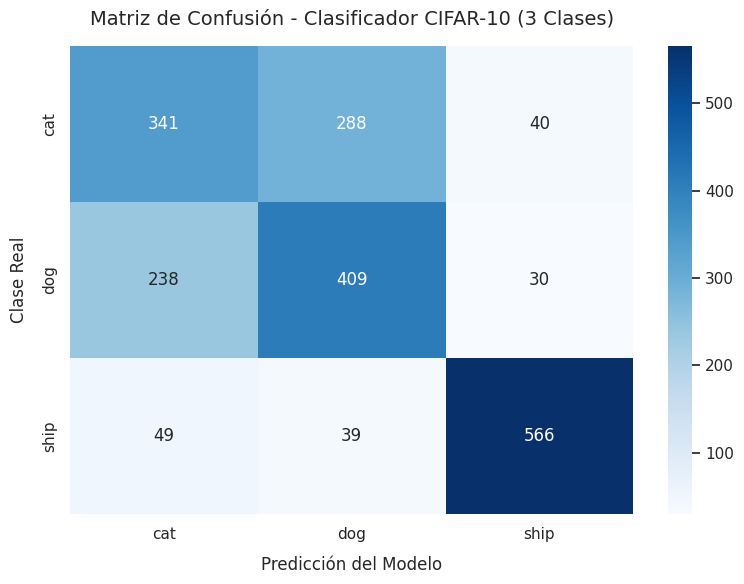

In [15]:
# Visualizar matriz de confusión

# Nombres de las clases mapeadas para el reporte gráfico
target_names = [class_names[sel_class] for sel_class in selected_classes]

# Generar gráfico de Matriz de Confusión
print("\nVisualizando la matriz de confusión ...")
plt.figure(figsize=(8, 6))
sns.set_theme(style='whitegrid')
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title('Matriz de Confusión - Clasificador CIFAR-10 (3 Clases)', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12, labelpad=10)
plt.ylabel('Clase Real', fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()

## 5. Ajuste de Hiperparámetros

Usamos las funciones anteriores para preparar un subconjunto del dataset de entrenamiento y prueba. Para que el entrenamiento sea rápido en un cuaderno interactivo, limitamos el número de muestras a ``max_samples``. Puedes ajustar ``max_samples`` o dejarlo como ``None`` para usar todas las imágenes, aunque esto requerirá más tiempo y memoria.

In [16]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from datetime import datetime

In [17]:
# 2. Setup the pipeline with scaling
pipe = Pipeline([
    # ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000))
])

# 3. Define the parameter grid
param_grid = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__solver': ['liblinear', 'saga'] # liblinear/saga support l1
}

# 4. Instantiate Grid Search
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)


In [ ]:
# 5. Fit the model

# Iniciar medición
start_time = time.time()

# Ejecutar la función
print(f'\nIniciando entrenamiento del modelo a {datetime.fromtimestamp(start_time).strftime('%Y-%m-%d %H:%M:%S.%f')}')
grid.fit(X_train_feat, y_train_sub)

# Finalizar medición
finish_time = time.time()
print(f'Finalizando entrenamiento del modelo a {datetime.fromtimestamp(finish_time).strftime('%Y-%m-%d %H:%M:%S.%f')}')
print(f'Tiempo de ejecución de entrenamiento del modelo: {finish_time - start_time:.4f} segundos')


Iniciando entrenamiento del modelo a 2026-05-25 18:45:50.524323


In [ ]:
# 6. Results
print("Best Hyperparameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)

# 7. Evaluate on Test Set
y_pred = grid.predict(X_test_feat)
print("Test Set Accuracy:", accuracy_score(y_test_sub, y_pred))